In [6]:
from transformers import AutoTokenizer
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback")

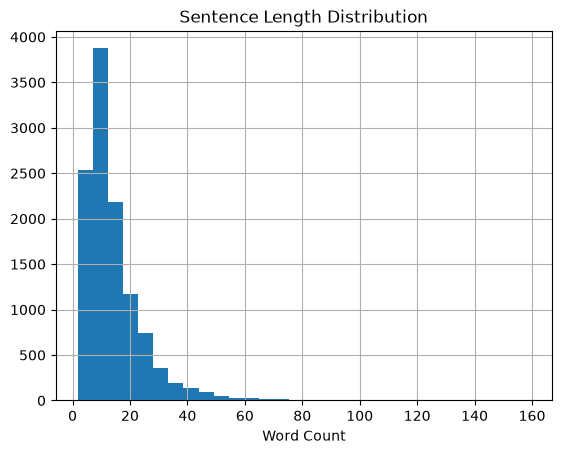

In [12]:
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

label_map = {0: "negative", 1 : "neutral", 2 : "positive"}
df_train['label_name'] = df_train['sentiment'].map(label_map)

df_train['length'] = df_train['sentence'].apply(lambda x: len(x.split()))
df_train['length'].hist(bins=30)
plt.xlabel('Word Count')
plt.title("Sentence Length Distribution")
plt.show()

In [14]:
dist = df_train["label_name"].value_counts()
print(dist)
print((dist / len(df_train) * 100).round(2))

label_name
positive    5643
negative    5325
neutral      458
Name: count, dtype: int64
label_name
positive    49.39
negative    46.60
neutral      4.01
Name: count, dtype: float64


In [18]:
for label in ['negative', 'positive', 'neutral']:
    print(f"\n--- {label} ---")
    print(df_train[df_train['label_name'] == label]['sentence'].sample(3).values)


--- negative ---
<ArrowStringArray>
['phòng máy quá nóng , nhỏ , trang thiết bị ít , máy rất cũ , hư nhiều .',
                         'tiết học có chút chán , có chút khó tiếp thu .',
                                      'không dạy bài tập cho sinh viên .']
Length: 3, dtype: str

--- positive ---
<ArrowStringArray>
['thầy dạy hay , hướng dẫn tận tình .',    'thầy giảng dạy hay và hiệu quả .',
  'thầy dạy tốt , cho bài tập nhiều .']
Length: 3, dtype: str

--- neutral ---
<ArrowStringArray>
[                                                                          'nhiều hoạt động .',
 'riêng bản thân em nhận thấy mình có thể học môn này mà không tham gia học đầy đủ trên lớp .',
                   'gặp giáo viên cũng chỉ là biết mặt để thầy cô còn chấm điểm đồ án hi hi .']
Length: 3, dtype: str
